# **Group information**
- Class: ML Labs 23KHDL1
- Group: 3
- Authors: 
    - 23127102 - Lê Quang Phúc
    - 23127212 - Nguyễn Quang Đăng Khoa
    - 23127241 - Đoàn Thành Phát
    - 23127332 - Trần Tiến Cường
    - 23127442 - Trầm Hữu Nhân


# **Data preprocessing**

## 1. Libraries

In [1]:
import os
import glob
import pandas as pd
import re
import ast
import unicodedata 
import time
import json

from dotenv import load_dotenv
from google import genai
from tqdm import tqdm
from google.genai import types
from pydantic import BaseModel
from urllib.parse import urlparse, urlencode, parse_qs

## 2. Aggregate data

In [4]:
data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data')
output_file = os.path.join(data_dir, 'data.csv')
csv_files = sorted(glob.glob(os.path.join(data_dir, '*.csv')))

header = ['name', 'address', 'score', 'nums_comments', 'price', 'category', 'hours', 'comments', 'comment_scores', 'url']

dfs = []

for csv_file in csv_files:
    if os.path.basename(csv_file) == 'data.csv':
        continue
        
    try:
        df = pd.read_csv(csv_file)
        df = df.iloc[:, :10]
        df.columns = header
        df = df.dropna(how='all')
        dfs.append(df)
    except Exception as e:
        print(f"Bỏ qua file {os.path.basename(csv_file)} vì lỗi: {e}")

if dfs:
    combined_df = pd.concat(dfs, ignore_index=True)
    combined_df.to_csv(output_file, index=False, encoding='utf-8-sig')

data = pd.read_csv(output_file)
print(f"Data shape (rows, columns): {data.shape}")

Data shape (rows, columns): (6050, 10)


In [45]:
# Read csv file
data = pd.read_csv('../data/data.csv')

## 3. Data overview

### 3.1 Context
This is a dataset compiling information collected from platforms (Google Maps, Booking, Foody) focusing primarily on accommodation, restaurants, eateries, and tourist attractions in Ho Chi Minh City. For ease of use in later stages, the team will consolidate the data into a single file, `data.csv`.

### 3.2 Features description


In [5]:
# 1. Định nghĩa từ điển mô tả cho các cột trong data.csv
column_desc = {
    'name': ['Location name', '-'],
    'address': ['Location address', '-'],
    'score': ['Rating score', 'Star (0.0 - 5.0)'],
    'nums_comments': ['Total of comments', 'Comment count'],
    'price': ['Price', 'VNĐ'],
    'category': ['Category', 'Attraction, Hotel, Dinning'],
    'hours': ['Operation hours', 'Opening hour - Closing hour'],
    'comments': ['List of comments', 'List of strings'],
    'comment_scores': ['List of comment scores', 'List of floats (0.0 - 5.0)'],
    'url': ['Path', '-']
}

# 2. Tạo DataFrame từ kiểu dữ liệu (dtypes) của bộ dữ liệu
data_dict = pd.DataFrame(data.dtypes, columns=['Data type'])
data_dict.reset_index(inplace=True)
data_dict.rename(columns={'index': 'Feature'}, inplace=True)

# 3. Ánh xạ (map) Description và Unit từ dictionary vào DataFrame
data_dict['Description'] = data_dict['Feature'].apply(lambda x: column_desc.get(x, ['N/A', 'N/A'])[0])
data_dict['Unit'] = data_dict['Feature'].apply(lambda x: column_desc.get(x, ['N/A', 'N/A'])[1])

# 4. Sắp xếp lại thứ tự các cột cho dễ nhìn
data_dict = data_dict[['Feature', 'Description', 'Unit', 'Data type']]

# 5. Hiển thị bảng Data Dictionary với định dạng căn trái
styled_dict = data_dict.style.hide(axis='index') \
    .set_properties(**{'text-align': 'left'}) \
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])

display(styled_dict)

Feature,Description,Unit,Data type
name,Location name,-,str
address,Location address,-,str
score,Rating score,Star (0.0 - 5.0),float64
nums_comments,Total of comments,Comment count,float64
price,Price,VNĐ,str
category,Category,"Attraction, Hotel, Dinning",str
hours,Operation hours,Opening hour - Closing hour,str
comments,List of comments,List of strings,str
comment_scores,List of comment scores,List of floats (0.0 - 5.0),str
url,Path,-,str


### 3.3 Data info

In [ ]:
print(f"- Data shape (rows, columns): {data.shape}")

# Những dòng dầu
display(data.head())
print("\n")

# Thông tin tổng quan về bộ dữ liệu
data.info()
print("\n")

- Kích thước của bộ dữ liệu (dòng, cột): (6050, 10)


,name,address,score,nums_comments,price,category,hours,comments,comment_scores,url
0,*BOM HOMES* VINHOMES CENTRAL PARK- LUXURY APAR...,"208 Nguyễn Hữu Cảnh, Quận Bình Thạnh, TP. Hồ ...",0.5,3.0,1350000,hotel,00:00 - 23:59,['Quá tệ. Booking xác nhận. Chủ nhà hủy ko báo...,"[0,5; 0,5; 0,5]",https://www.booking.com/hotel/vn/bom-homes-vin...
1,1 AM Home Sai Gon,109/14 Đường Nguyễn Thiện Thuật Toà nhà có tần...,4.5,8.0,770000,hotel,00:00 - 23:59,"['Phòng đẹp ơi là đẹp, rộng rãi thoải mái, sán...",[5; 5; 5; 4; 4; 4; 5; 4],https://www.booking.com/hotel/vn/1-am-homestay...
2,1 Bedroom Apartment Cozy Canal View Hoang Sa s...,"287 Đường Hoàng Sa, Quận 1, 123080 TP. Hồ Chi...",0.0,0.0,1399000,hotel,00:00 - 23:59,[],[],https://www.booking.com/hotel/vn/1-bedroom-apa...
3,1 Bedroom Apartment Landmark Plus Lp,"208 Đường Nguyễn Hữu Cảnh, Quận Bình Thạnh, TP...",4.5,1.0,1288888,hotel,00:00 - 23:59,['The support and friendliness from the staff....,"[4,5]",https://www.booking.com/hotel/vn/1-bedroom-apa...
4,1 Bedroom Daisy - Luxury Gold Apartment - Cent...,"538/2/5 Đoàn Văn Bơ, 72800 TP. Hồ Chí Minh, ...",0.0,0.0,750000,hotel,00:00 - 23:59,[],[],https://www.booking.com/hotel/vn/1-bedroom-dai...




<class 'pandas.DataFrame'>
RangeIndex: 6050 entries, 0 to 6049
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            6050 non-null   str    
 1   address         6050 non-null   str    
 2   score           5978 non-null   float64
 3   nums_comments   5978 non-null   float64
 4   price           4219 non-null   str    
 5   category        6050 non-null   str    
 6   hours           5296 non-null   str    
 7   comments        6047 non-null   str    
 8   comment_scores  6045 non-null   str    
 9   url             6045 non-null   str    
dtypes: float64(2), str(8)
memory usage: 472.8 KB




### 3.4 Data preprocessing

#### 3.4.1 Data standardization
The data standardi step aims to standardize the values ​​in each column, eliminate noise, and convert data types to suit subsequent analysis steps.

Column `name`
- Convert to string format, remove extra spaces and special characters.
- Standardize Unicode to NFC (Canonical Decomposition followed by Canonical Composition) format to standardize the representation of Vietnamese characters.

Column `address`
- Remove rows with empty or null addresses.
- Remove spaces, extra characters, and standardize Unicode NFC similarly to the `name` column.
- Remove country suffixes, city name variations, and postal codes.

Column `score`: Convert to floating-point numbers, replace invalid values ​​with 0, and cast to `float32` to save memory.

Column `nums_comments`
Convert to integer type, replace invalid values ​​with 0, cast to `int32`.

Column `price`
- Split the `price` column into `price_min` and `price_max` columns.
- Missing or invalid values ​​are assigned 0.
- Delete the original `price` column after splitting.

Column `category`
Removes spaces, capitalizes the first letter, and converts to the `category` type to optimize memory usage and support grouping/filtering operations.

Column `hours`
- Splits the Hours column into two columns: `Start` and `End`.
- If a value is missing or incorrectly formatted, it defaults to `'-'`.
- Deletes the original Hours column after splitting.

Column `comments`
- Standardizes the comment list to a consistent format `[{comment 1}, {comment 2}, ...]`.
- Removes line breaks (`\n`), reduces spaces, and deletes extra characters.
- Empty values ​​are assigned `'[]'`.

Column `comment_scores`
- Converts the semicolon-separated score string into a Python list (`list[float]`).
- Empty values ​​are assigned an empty list `[]`.

Column `url`
- Shortens the URL by removing the query string portion, the `/data=...` portion containing unnecessary metadata.

In [40]:
# Header
data.columns = data.columns.str.strip().str.capitalize()

# Name
data['Name'] = (data['Name']
    .astype(str)
    .str.strip()
    .str.replace(r'[*~#]', '', regex=True)
    .apply(lambda x: unicodedata.normalize('NFC', x))
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip(' -,.')
)

# Address
data = data[data['Address'].notna() & (data['Address'].str.strip() != '')].reset_index(drop=True)

def normalize_address(addr):
    if pd.isna(addr) or str(addr).strip() == '':
        return addr
    addr = str(addr).strip()

    addr = unicodedata.normalize('NFC', addr)
    
    addr = re.sub(r',?\s*(Việt Nam|Vietnam)\s*$', '', addr, flags=re.IGNORECASE)
    
    city_patterns = [
        r',?\s*Thành\s+[Pp]hố\s+Hồ\s+Chí\s+Minh',
        r',?\s*TP\.\s*Hồ\s+Chí\s+Minh',
        r',?\s*TP\.\s*HCM',
        r',?\s*TP\.HCM',
        r',?\s*TP\s*HCM',
        r',?\s*Hồ\s+Chí\s+Minh',
    ]
    for pattern in city_patterns:
        addr = re.sub(pattern, '', addr, flags=re.IGNORECASE)
    
    addr = re.sub(r',?\s*\b\d{5,6}\b', '', addr)
    
    addr = re.sub(r'\s*,\s*,\s*', ', ', addr)  
    addr = re.sub(r'\s+', ' ', addr)            
    addr = addr.strip().strip(',').strip()       
    
    return addr

data['Address'] = data['Address'].apply(normalize_address)

# Score
data['Score'] = pd.to_numeric(data['Score'], errors='coerce').fillna(0).astype('float32')

# Nums_comments
data['Nums_comments'] = pd.to_numeric(data['Nums_comments'], errors='coerce').fillna(0).astype('int32')

# Price
def parse_price(val):
    if pd.isna(val) or str(val).strip() == '':
        return (0, 0)
    val_str = str(val).strip()
    # Trường hợp dạng range: "số1-số2"
    if '-' in val_str:
        parts = val_str.split('-')
        try:
            p_min = int(parts[0].strip())
            p_max = int(parts[1].strip())
            return (p_min, p_max)
        except ValueError:
            return (0, 0)
    # Trường hợp đơn giá trị
    try:
        p = int(float(val_str))
        return (p, p)
    except ValueError:
        return (0, 0)

price_parsed = data['Price'].apply(parse_price)
data['Price_min'] = price_parsed.apply(lambda x: x[0]).astype('int32')
data['Price_max'] = price_parsed.apply(lambda x: x[1]).astype('int32')
data.drop(columns=['Price'], inplace=True)

# Category
data['Category'] = data['Category'].str.strip().str.capitalize().astype('category')

# Hours
def parse_hours(val):
    if pd.isna(val) or str(val).strip() == '':
        return ('-', '-')
    parts = str(val).strip().split(' - ')
    if len(parts) == 2:
        return (parts[0].strip(), parts[1].strip())
    return ('-', '-')

hours_parsed = data['Hours'].apply(parse_hours)
data['Start'] = hours_parsed.apply(lambda x: x[0]).astype('str')
data['End'] = hours_parsed.apply(lambda x: x[1]).astype('str')
data.drop(columns=['Hours'], inplace=True)

# Comments
def normalize_comments(val):
    if pd.isna(val) or str(val).strip() in ('', '[]'):
        return '[]'
    
    val_str = str(val).strip()
    
    try:
        items = ast.literal_eval(val_str)
        if isinstance(items, list):
            cleaned = []
            for item in items:
                s = str(item).strip().strip('"').strip("'").strip()
                s = s.replace('\n', ' ').replace('\\n', ' ')
                s = re.sub(r'\s+', ' ', s).strip()
                if s:
                    cleaned.append('{' + s + '}')
            return '[' + ', '.join(cleaned) + ']'
    except (ValueError, SyntaxError):
        pass
    
    if val_str.startswith('[') and val_str.endswith(']'):
        inner = val_str[1:-1]
        parts = re.split(r'\}\s*,\s*\{', inner)
        cleaned = []
        for part in parts:
            s = part.strip().strip('{').strip('}').strip()
            s = s.strip('"').strip("'").strip()
            s = s.replace('\n', ' ').replace('\\n', ' ')
            s = re.sub(r'\s+', ' ', s).strip()
            if s:
                cleaned.append('{' + s + '}')
        return '[' + ', '.join(cleaned) + ']'
    
    s = val_str.replace('\n', ' ').replace('\\n', ' ')
    s = re.sub(r'\s+', ' ', s).strip()
    return '[{' + s + '}]'

data['Comments'] = data['Comments'].apply(normalize_comments)

# Comment_scores
def parse_comment_scores(val):
    if pd.isna(val) or str(val).strip() in ('', '[]'):
        return []
    inner = str(val).strip().strip('[]')
    parts = [p.strip().replace(',', '.') for p in inner.split(';')]
    scores = []
    for p in parts:
        try:
            scores.append(float(p))
        except ValueError:
            continue
    return scores

data['Comment_scores'] = data['Comment_scores'].astype('object').apply(parse_comment_scores)

# Url
def shorten_url(url):
    url = str(url).strip()

    if 'booking.com' in url:
        return url.split('?')[0]

    if 'google.com/maps' in url:
        url = url.split('?')[0]
        url = url.split('/data=')[0]
        return url

    return url

data['Url'] = data['Url'].apply(shorten_url)

# obj_cols = data.select_dtypes(include=['object']).columns.difference(['Comment_scores']).difference(['Comments'])
# data[obj_cols] = data[obj_cols].astype('string')

#### 3.4.2 Remove duplicates

In [ ]:
dup_mask = data.duplicated(subset=["Name", "Address"], keep=False)
dup_rows = data[dup_mask].sort_values(["Name", "Address"])
print(f"Duplicates: {dup_rows.shape[0]}")

n_removed = data.duplicated(subset=["Name", "Address"], keep="first").sum()
data = data.drop_duplicates(subset=["Name", "Address"], keep="first").reset_index(drop=True)

print(f"Data shape after removing duplicates: {data.shape}")

Dữ liệu trùng nhau: 2
Kích thước sau khi xóa trùng lặp: (6049, 12)


#### 3.4.3 Data valid

In [ ]:
print("Score within [0, 5]:", data[(data['Score'] < 0) | (data['Score'] > 5)].shape[0])
print("Nums_comments < 0:", data[data['Nums_comments'] < 0].shape[0])
print("Price_min < 0:", data[data['Price_min'] < 0].shape[0])
print("Price_max < Price_min:", data[data['Price_max'] < data['Price_min']].shape[0])

Score ngoài [0, 5]: 0
Nums_comments < 0: 0
Price_min < 0: 0
Price_max < Price_min: 0


#### 3.4.4 Process `address` column
After the normalization step, the `address` column had its country suffix, city name, and postal code removed. However, the addresses were still in raw form with various formats (missing ward/district, containing building names, inconsistent order, etc.). This step involved calling the **Gemini API** to normalize all addresses to a unified format: **"[house number] [street name], [ward], [district]"**, in order to provide complete location information and facilitate the extraction of wards/districts in subsequent analysis tasks.

**How ​​to do it:**
1. **Extract unique addresses:** Get a set of non-duplicate `Address` values ​​to minimize the number of API calls (instead of processing each line, only process distinct addresses).
2. **Batching:** Group addresses into batches of 50 addresses/request due to the limitations of the free API key.
3. **Calling Gemini API:** Each batch is sent with a prompt requesting LLM to normalize addresses according to the following rules:
- Keep the house number and street name.
- Infer the ward/district if missing but identifiable from the context.
- Remove extraneous information (building name, description, floor number, etc.).
- Return results in JSON format with a fixed schema (`id`, `address`) with `temperature=0.1` to ensure consistency.
4. **Error handling:** Each batch is tried a maximum of 3 times. If it still fails, keep the original address to avoid data loss.
5. **Backward mapping:** Build a mapping table from raw addresses to normalized addresses, then update the entire `address` column in the original DataFrame.

**Result:** 
All addresses in the `address` column are converted to a standardized format, unifying the data structure and facilitating the extraction of district and ward information for subsequent analysis and visualization steps.

In [ ]:
load_dotenv()

# Khởi tạo Client
client = genai.Client()

class AddressResult(BaseModel):
    id: int
    address: str  

# Hàm gọi API 
def process_address_batch(batch_data, max_retries=3):
    prompt = f"""Bạn là chuyên gia chuẩn hóa địa chỉ tại TP. Hồ Chí Minh, Việt Nam.

Hãy chuẩn hóa các địa chỉ thô sau theo format: "[số nhà] [tên đường], [phường], [quận]"

Quy tắc:
- Giữ lại số nhà và tên đường chính xác.
- Suy luận phường/quận nếu thiếu nhưng có thể xác định được từ ngữ cảnh.
- Nếu không xác định được phường, bỏ qua phần phường: "[số nhà] [đường], [quận]".
- Loại bỏ thông tin phụ không liên quan (tên tòa nhà, mô tả, số tầng...).
- Giữ đúng id tương ứng với từng địa chỉ đầu vào.

Dữ liệu:
{json.dumps(batch_data, ensure_ascii=False)}"""

    for attempt in range(max_retries):
        try:
            response = client.models.generate_content(
                model='gemini-2.5-flash',
                contents=prompt,
                config=types.GenerateContentConfig(
                    response_mime_type="application/json",
                    response_schema=list[AddressResult],
                    temperature=0.1
                )
            )
            return json.loads(response.text)
        except Exception as e:
            print(f"\nThử lại lần {attempt + 1}: {e}")
            if attempt < max_retries - 1:
                time.sleep(15)  
    return None

# Xử lý các dòng địa chỉ duy nhất -> giảm lượt gọi API
unique_addresses = data['Address'].unique()
print(f"Tổng dòng xử lý: {len(data)} | Địa chỉ duy nhất: {len(unique_addresses)}")
print(f"Số batch cần gọi API: {(len(unique_addresses) - 1) // 50 + 1}")

df_unique = pd.DataFrame({
    'id': range(len(unique_addresses)),
    'raw_address': unique_addresses
})

# Gom các dòng dữ liệu theo batch cho mỗi request (vì dùng API key free bị giới hạn số request)
BATCH_SIZE = 50
all_results = []
failed_batches = []

for i in tqdm(range(0, len(df_unique), BATCH_SIZE), desc="Đang xử lý"):
    chunk = df_unique.iloc[i:i + BATCH_SIZE]
    batch_records = chunk.to_dict('records')

    result = process_address_batch(batch_records)

    if result is not None:
        all_results.extend(result)  
    else:
        failed_batches.append(i)
        # Nếu lỗi thì giữ nguyên địa chỉ ban đầu
        for rec in batch_records:
            all_results.append({"id": rec["id"], "address": rec["raw_address"]})

    time.sleep(5) 

# 6. Map kết quả ngược về DataFrame gốc
result_df = pd.DataFrame(all_results)
merged = df_unique.merge(result_df, on='id', how='left')
address_map = dict(zip(
    merged['raw_address'],
    merged['address'].fillna(merged['raw_address'])
))
data['Address'] = data['Address'].map(address_map).fillna(data['Address'])

Tổng dòng xử lý: 479 | Địa chỉ duy nhất: 477
Số batch cần gọi API: 10


Đang xử lý: 100%|██████████| 10/10 [10:26<00:00, 62.66s/it]


#### 3.4.5 Results

In [ ]:
# Thống kê
print("- Data type: \n", data.dtypes, "\n")
print("- Missing values: \n", data.isnull().sum(), "\n")
print("- Statistics: \n", data.describe().T, "\n")

# Lưu file kết quả sau khi đã tiền xử lý
data = data[['Name', 'Address', 'Score', 'Nums_comments', 'Price_min', 'Price_max', 'Category', 'Start', 'End', 'Comments', 'Comment_scores', 'Url']]
output_processed = os.path.join(data_dir, 'processed_data.csv')
data.to_csv(output_processed, index=False, encoding='utf-8-sig')

- Kiểu dữ liệu: 
 Name                   str
Address                str
Score              float32
Nums_comments        int32
Category          category
Comments               str
Comment_scores      object
Url                    str
Price_min            int32
Price_max            int32
Start                  str
End                    str
dtype: object 

- Dữ liệu thiếu: 
 Name              0
Address           0
Score             0
Nums_comments     0
Category          0
Comments          0
Comment_scores    0
Url               0
Price_min         0
Price_max         0
Start             0
End               0
dtype: int64 

- Thống kê mô tả: 
                 count           mean           std  min  25%       50%  \
Score          6049.0       3.440899  1.529090e+00  0.0  3.2       4.0   
Nums_comments  6049.0     413.182840  2.192863e+03  0.0  4.0      42.0   
Price_min      6049.0  696407.948587  1.341629e+06  0.0  0.0   50000.0   
Price_max      6049.0  727699.568524  1.333201e+06  

# **Data visualization**

## 1. Libraries

In [7]:
import re
import ast
import time as _time
import warnings
import requests
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import os
import json

from matplotlib.ticker import FuncFormatter, ScalarFormatter, LogLocator
from matplotlib.colors import LogNorm
from wordcloud import WordCloud
from folium.plugins import MarkerCluster

# Cấu hình ban đầu
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

In [8]:
df = pd.read_csv("../data/processed_data.csv")

## 2. Setting and preprocessing

This section loads all necessary libraries and performs preliminary data preprocessing before analysis.
- **Visualization libraries**: `matplotlib`, `seaborn`, `plotly` are used for plotting charts.
- **Data processing**: `pandas`, `numpy` are used for manipulating and calculating on DataFrames.
- **Text processing**: `wordcloud` is used to analyze comment content.
- **Complex column parsing**: `comments` (in the format `[{text}, ...]`) and `comment_scores` (in the format of a list of numbers) are converted to Python `list` using custom preprocessing functions.
- **Column creation**: `price_mean = (price_min + price_max) / 2` is pre-calculated for price analysis.

In [9]:
def parse_comments(x):
    """Trích xuất danh sách bình luận từ chuỗi văn bản."""
    if not isinstance(x, str) or x.strip() in ['[]', '']:
        return []
    return re.findall(r'\{(.*?)\}', x, re.DOTALL)

def parse_scores(x):
    """Chuyển đổi chuỗi định dạng list thành danh sách số thực."""
    if not isinstance(x, str) or x.strip() in ['[]', '']:
        return []
    try:
        return ast.literal_eval(x)
    except Exception:
        return []

df['Category'] = df['Category'].astype('category')
df['Comments'] = df['Comments'].apply(parse_comments)
df['Comment_scores'] = df['Comment_scores'].apply(parse_scores)
df['Price_mean'] = (df['Price_min'] + df['Price_max']) / 2

price_fmt = FuncFormatter(lambda x, _: f'{x:,.0f}')

## 3 Univariate analysis
The goal of this section is to examine the distribution characteristics of each variable independently,
including assessing the distribution shape, identifying outliers, and recognizing notable locations for
each individual indicator.

### 3.1 Category distribution (`category`)
The goal of this section is to identify the **component structure** of the dataset according to three main categories.
Two charts are used to illustrate:
- **Pie chart**: shows the **percentage** of each category (Attraction, Hotel, Dining) in the entire dataset, helping to identify which category is dominant.
- **Bar chart**: shows the **absolute number** of locations within each category, allowing for direct comparison of scale between groups.

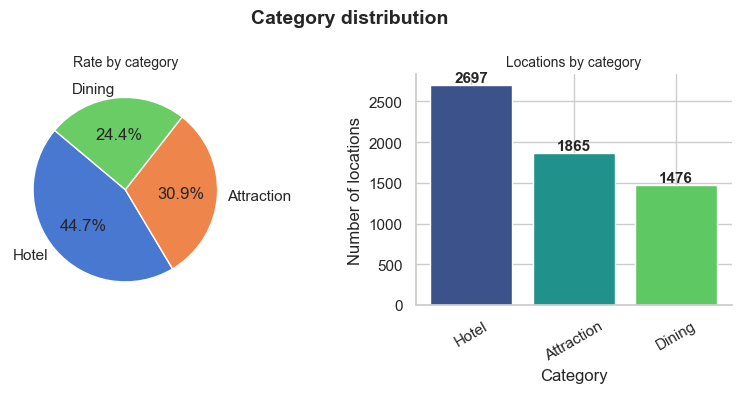

In [5]:
cat_counts = df['Category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle('Category distribution', fontsize=14, fontweight='bold')

# Pie chart - Tỷ trọng %
pie_colors = sns.color_palette("muted", len(cat_counts))
axes[0].pie(
    cat_counts.values,
    labels=cat_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=pie_colors
)
axes[0].set_title('Rate by category', fontsize=10)

# Bar chart - Số lượng tuyệt đối
bar_colors = sns.color_palette("viridis", len(cat_counts))
bars = axes[1].bar(cat_counts.index, cat_counts.values, color=bar_colors)

axes[1].set_title('Locations by category', fontsize=10)
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number of locations')
axes[1].tick_params(axis='x', rotation=30)

# Hiển thị giá trị trên mỗi cột
for bar in bars:
    axes[1].annotate(
        f'{int(bar.get_height())}',
        xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


**Insights:**
- Dataset focuses primarily on the hotel category, accounting for an overwhelming 44.6% (equivalent to 2698 locations).
- The attraction and dining categories account for lower percentages, at 30.9% (1870 locations) and 24.4% (1478 locations) respectively.
- This disparity indicates a slight imbalance in the dataset, favoring accommodation servicesover entertainment and dining venues.

### 3.2 Distribution of scores, prices, and comments (`score`, `price_mean`, `nums_comments`)

The goal of this section is to analyze the **distribution shape** of the continuous variables in the dataset.

Four histograms combined with density lines (KDEs) are plotted for each variable:
- **Score**: distribution of the average rating of the locations.
- **Price_min / Price_max**: distribution of the service price range, often right-skewed due to the presence of high-end locations.
- **Nums_comments**: distribution of the number of comments, reflecting the popularity and engagement of each location.

Statistical indicators **skewness**, **kurtosis**, and **median** are displayed directly on each histogram to aid in quick evaluation.

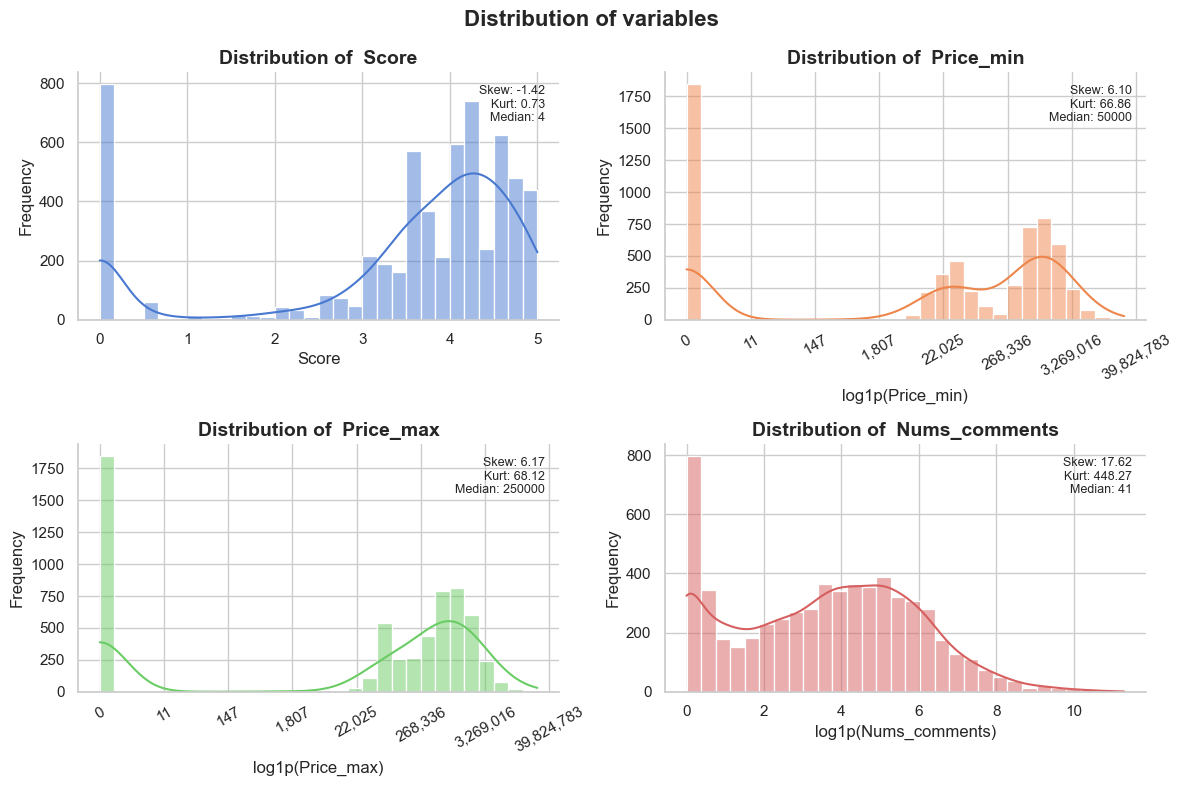

In [6]:
num_vars  = ['Score', 'Price_min', 'Price_max', 'Nums_comments']
pal_muted = sns.color_palette('muted', 4)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
fig.suptitle('Distribution of variables', fontsize=16, fontweight='bold')

for i, col in enumerate(num_vars):
    data_col = df[col].dropna()
    if col in ('Price_min', 'Price_max', 'Nums_comments'):
        data_plot = np.log1p(data_col)
        label = f'log1p({col})'
        sns.histplot(data_plot, kde=True, ax=axes[i], color=pal_muted[i], bins=30)
        axes[i].set_xlabel(label)
        skew_val = data_col.skew()
        kurt_val = data_col.kurt()
        median_val = data_col.median()
        axes[i].text(
            0.97, 0.95,
            f'Skew: {skew_val:.2f}\nKurt: {kurt_val:.2f}\nMedian: {median_val:.0f}',
            transform=axes[i].transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0)
        )
        if col in ('Price_min', 'Price_max'):
            axes[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{np.expm1(x):,.0f}'))
            axes[i].tick_params(axis='x', rotation=30)
    else:
        sns.histplot(data_col, kde=True, ax=axes[i], color=pal_muted[i], bins=30)
        axes[i].set_xlabel(col)
        skew_val = data_col.skew()
        kurt_val = data_col.kurt()
        median_val = data_col.median()
        axes[i].text(
            0.97, 0.95,
            f'Skew: {skew_val:.2f}\nKurt: {kurt_val:.2f}\nMedian: {median_val:.0f}',
            transform=axes[i].transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0)
        )
    axes[i].set_title(f'Distribution of  {col}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Insights:**
- `Score` variable is left-skewed, mainly concentrated at high scores (median is 4), but a large amount of data is clustered at 0 points (locations that have not received reviews).
- The price variables (`price_min, price_max`) and interaction volume (`nums_comments`) are both extremely right-skewed with very high kurtosis.
- This indicates that most locations are in the budget price segment and have few comments (median is only 42), but there is a small group of outliers with extremely high values that need to be considered before modeling.

### 3.3 Outliers by variable (`score`, `price_mean`, `nums_comments`)

The goal of this section is to **identify the core distribution range** and **detect outliers** of continuous variables.

Four boxplots are presented in parallel for comparison:
- **Box (IQR)**: covers 50% of the central data (Q1 to Q3).
- **Whistle**: represents the range of valid data according to the 1.5×IQR rule.
- **Red dots**: observations that fall outside the IQR threshold, identified as **outliers**; the number and percentage of outliers are noted below each plot.

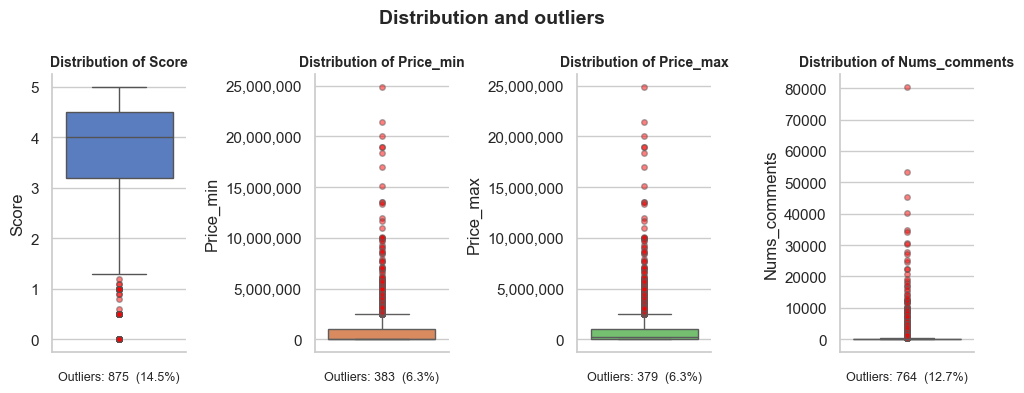

In [9]:
num_vars = ['Score', 'Price_min', 'Price_max', 'Nums_comments']

fig, axes = plt.subplots(1, 4, figsize=(10, 4))
fig.suptitle('Distribution and outliers', fontsize=14, fontweight='bold')

for i, col in enumerate(num_vars):
    data_col = df[col].dropna()
    sns.boxplot(y=data_col, ax=axes[i], color=sns.color_palette('muted')[i],
                flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))
    axes[i].set_title(f'Distribution of {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel(col)

    if col in ('Price_min', 'Price_max'):
        axes[i].yaxis.set_major_formatter(price_fmt)

    # Tính số lượng outliers theo quy tắc IQR
    q1, q3 = data_col.quantile(0.25), data_col.quantile(0.75)
    iqr = q3 - q1
    n_out = ((data_col < q1 - 1.5 * iqr) | (data_col > q3 + 1.5 * iqr)).sum()
    axes[i].set_xlabel(f'Outliers: {n_out}  ({n_out/len(data_col)*100:.1f}%)', fontsize=9)

plt.tight_layout()
plt.show()


**Insights:**
- All four variables recorded a significant percentage of outliers, ranging from 6.3% to 14.5% of the total observations. 
- For the score variable, outliers were concentrated at very low scores (below 1.5), reflecting a small group of poorly rated or unrated locations.
- Conversely, the price variables (‘price_min, price_max‘) and interaction variables (nums_comments‘) showed persistent outliers at their maximum values, indicating a large disparity between the group of ordinary budget locations and a small number of ultra-luxury or highly viral locations.

### 3.4 The highest rating with the most comments (`score`, `nums_comments`)
The goal of this section is to rank the locations with the highest service quality based on user reviews.

To ensure **statistical significance**, only locations with **over 2,000 reviews** are included in the ranking — excluding locations with fewer reviews that may have high scores but lack representativeness.

- **Horizontal bar chart**: displays the Top 10 locations ranked in descending order of score, with direct value labels on each bar.

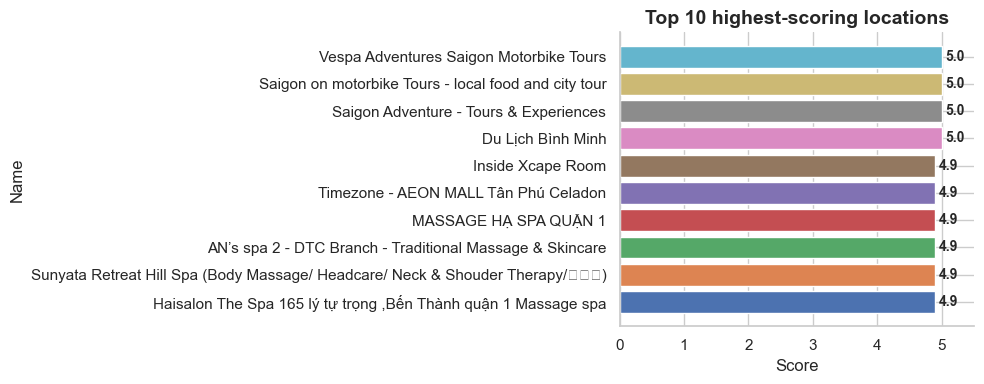

In [10]:
top10_score = (
    df[df['Nums_comments'] > 2000]
    .nlargest(10, 'Score')[['Name', 'Score', 'Category', 'Nums_comments']]
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(
    top10_score['Name'][::-1],
    top10_score['Score'][::-1],
    color=sns.color_palette("deep", len(top10_score))
)

ax.set_title('Top 10 highest-scoring locations', fontsize=14, fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Name')
ax.set_xlim(0, top10_score['Score'].max() + 0.5)

# Hiển thị giá trị điểm trên mỗi thanh
for bar in bars:
    ax.annotate(
        f'{bar.get_width():.1f}',
        xy=(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2),
        va='center', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()


**Insights:**
- The top 10 highest-scoring locations received near-perfect ratings, ranging from 4.9 to 5.0.
- The leading group in the rankings mainly consists of services offering unique experiences such as motorbike tours, street food tours, and wellness facilities (spas, massages).
- This reflects the superior level of user satisfaction with business models that provide deeply personalized experiences, rather than mass-market accommodation or dining services.

### 3.5 Highest number of comments (`nums_comments`)
The goal of this section is to identify locations with the **highest level of community engagement** through the number of comments.

- **Horizontal bar chart**: ranks the Top 10 locations in descending order of the number of comments; corresponding scores are displayed to compare popularity and perceived quality.

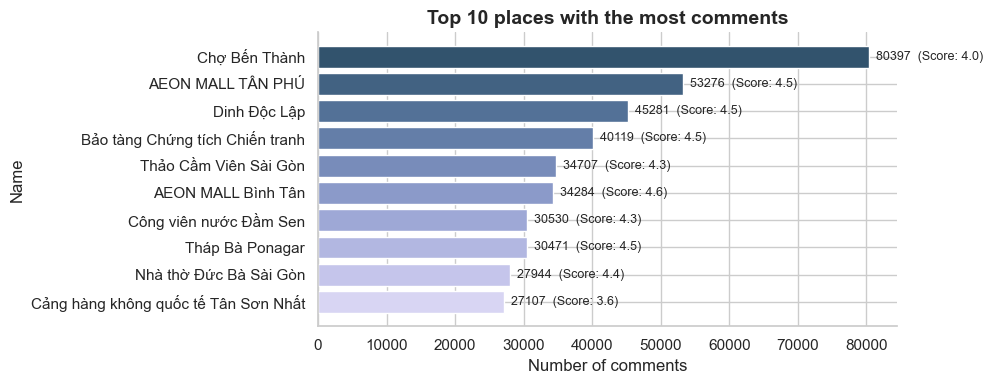

In [ ]:
top10_comments = (
    df.nlargest(10, 'Nums_comments')[['Name', 'Nums_comments', 'Score', 'Category']]
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 4))
palette = sns.cubehelix_palette(10, start=2.5, rot=0.2, dark=0.3)
bars = ax.barh(top10_comments['Name'][::-1], top10_comments['Nums_comments'][::-1],
               color=palette, edgecolor='white')

ax.set_title('Top 10 locations with the most comments',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of comments')
ax.set_ylabel('Name')

# Hiển thị giá trị trên thanh + điểm số tương ứng
for j, bar in enumerate(bars):
    idx = 9 - j
    score = top10_comments.loc[idx, 'Score']
    ax.annotate(
        f'  {int(bar.get_width())}  (Score: {score})',
        xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
        va='center', fontsize=9
    )

plt.tight_layout()
plt.show()


**Insights:**
- Ben Thanh Market attracted the most interaction with over 80,000 comments, creating a significant gap between it and the second place location.
- The top 10 most popular locations mainly focused on iconic cultural and historical land- marks and large-scale shopping malls.
- Notably, the massive volume of reviews did not entirely reflect the level of satisfaction; while commercial areas maintained very positive scores (4.5 - 4.6), public areas such as airports or traditional markets recorded more modest scores (3.6 - 4.0).

## 4 Multivariate analysis

The goal of this section is to explore the **relationships** and **interactions** between variables, including category-based comparisons, correlation analysis, geospatial visualization, and analysis of combined indicators such as Value-for-Money.

### 4.1 Comparison by category (`category`, `score`, `nums_comments`, `price_mean`)
The goal of this section is to synthesize and compare the **overall performance of each location category** across three key metrics.

Three grouped bar charts are used to illustrate:
- **Average score (Avg_score)**: compares the average service quality across the Attraction, Hotel, and Dining categories.
- **Average price Max (Avg_price_max)**: reflects the typical price segment of each category.
- **Average comments (Avg_comments)**: measures the level of engagement and relative popularity of each category.

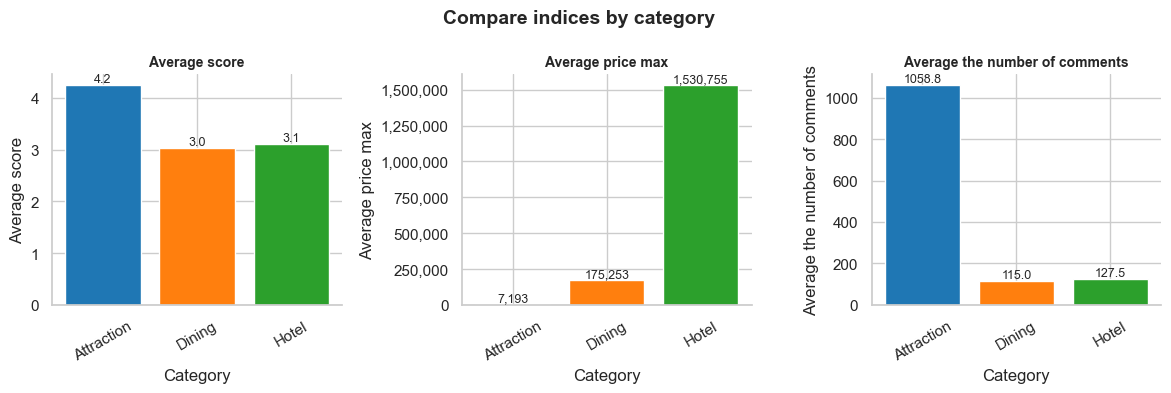

In [13]:
cat_stats = (
    df.groupby('Category', observed=True)
    .agg(
        Count          = ('Name',         'count'),
        Avg_Score      = ('Score',        'mean'),
        Avg_Price_min  = ('Price_min',    'mean'),
        Avg_Price_max  = ('Price_max',    'mean'),
        Avg_Comments   = ('Nums_comments','mean'),
    )
    .round(2)
    .reset_index()
)

# Bar chart nhóm cho 3 chỉ số chính
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Compare indices by category', fontsize=14, fontweight='bold')

metrics = [
    ('Avg_Score',    'Average score',    'deep'),
    ('Avg_Price_max','Average price max', 'muted'),
    ('Avg_Comments', 'Average the number of comments',     'tab10'),
]

for ax, (col, title, pal) in zip(axes, metrics):
    bars = ax.bar(
        cat_stats['Category'],
        cat_stats[col],
        color=sns.color_palette("tab10", len(cat_stats))
    )
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Category')
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=30)
    if col in ('Avg_Price_min', 'Avg_Price_max'):
        ax.yaxis.set_major_formatter(price_fmt)
    for bar in bars:
        val = bar.get_height()
        label = f'{val:,.0f}' if col in ('Avg_Price_min', 'Avg_Price_max') else f'{val:.1f}'
        ax.annotate(label,
                    xy=(bar.get_x() + bar.get_width()/2, val),
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


**Insights:**
- The attraction group recorded the highest level of interaction and satisfaction, with an average score of 4.2 and nearly 10 times more comments (1061.2) than the other groups.
- Conversely, the hotel group had the biggest financial barrier with a significantly higher average maximum price (over 1.5 million VND), far surpassing the dinnings and attractions.
- Notably, despite the huge price difference, both the hotel and dining groups shared relatively modest average scores (3.0 - 3.1) and low interaction levels, indicating that service costs are not directly proportional to user satisfaction.

### 4.2 The relationship between scores and the number of comments (`score`, `nums_comments`)
The goal of this section is to examine the relationship between the **number of comments** and the **ratings** of locations.

- **Category colored scatter plot**: each point represents a location; colors distinguish categories.
- **Log line trend**: reflects the overall trend between two variables, where the X-axis (number of comments) is represented on a logarithmic scale to handle heavily skewed distributions.
- **Pearson correlation coefficient (r)** is directly displayed on the chart header to provide a quantitative measure of the degree of linear correlation.


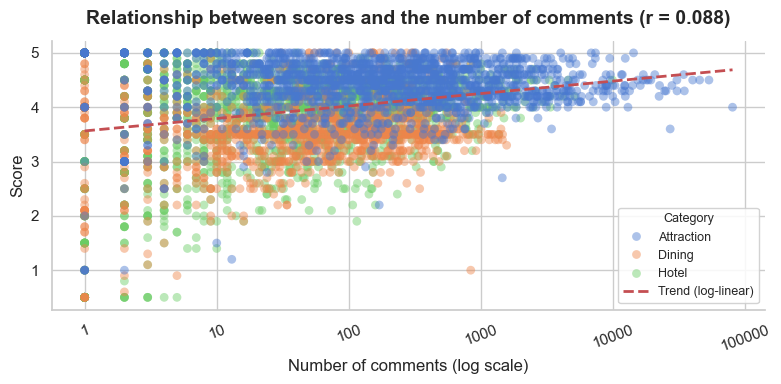

In [14]:
df_plot = df.dropna(subset=['Score', 'Nums_comments'])
df_plot = df_plot[df_plot['Nums_comments'] > 0].copy()

# Pearson r (trên thang gốc)
corr = df_plot['Nums_comments'].corr(df_plot['Score'])

# Hồi quy tuyến tính trên log10
log10_x = np.log10(df_plot['Nums_comments'])
m, b = np.polyfit(log10_x, df_plot['Score'], 1)

x_range  = np.logspace(
    np.log10(df_plot['Nums_comments'].min()),
    np.log10(df_plot['Nums_comments'].max()),
    300
)
y_trend  = m * np.log10(x_range) + b

# Vẽ scatter plot với đường xu hướng log-linear
fig, ax = plt.subplots(figsize=(8, 4))

sns.scatterplot(
    data=df_plot,
    x='Nums_comments',
    y='Score',
    hue='Category',
    palette='muted',
    alpha=0.45,
    s=40,
    edgecolor='none',
    ax=ax
)

# Đường xu hướng
ax.plot(x_range, y_trend,
        color='#C44E52', linestyle='--', linewidth=2,
        label=f'Trend (log-linear)', zorder=5)

# Log scale trên trục X
ax.set_xscale('log')
formatter = ScalarFormatter()
formatter.set_scientific(False)
ax.xaxis.set_major_formatter(formatter)
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=8))
ax.tick_params(axis='x', rotation=20)

# Nhãn & tiêu đề
ax.set_title(
    f'Relationship between scores and the number of comments (r = {corr:.3f})',
    fontsize=14, fontweight='bold', pad=12
)
ax.set_xlabel('Number of comments (log scale)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Category',
          loc='lower right', fontsize=9, title_fontsize=9,
          framealpha=0.85, edgecolor='#cccccc')

plt.tight_layout()
plt.show()


**Insights:**
- The low correlation coefficient (r = 0.089) indicates that there is almost no clear linear relationship between the number of reviews and the rating of a location.
- Attractions completely dominates the high-scoring and high-engagement areas (exceeding 10000 reviews), suggesting that popular tourist destinations generally maintain very high levels of satisfaction from the public.
- Meanwhile, Hotel and dining groups are more scattered across the lower-scoring ranges and rarely attract more than 1000 reviews, reflecting the fragmented nature, conflicting opinions, and difficulty in satisfying the majority of these two service groups.

### 4.3 Value for money by category (`price_mean`, `score`, `category`)
The goal of this section is to assess the **"value for money"** of each location category based on the correlation between quality and cost.

The Value-for-Money Index is defined as:

$$\text{Value Index} = \frac{\text{Median Score}}{\log_{10}(\text{Median Price})}$$

- **Horizontal bar chart**: compares the value for money index between categories — a higher value indicates better quality for the price paid.

- The corresponding median price is indicated with a label for each column for easy reference.

**Note:**
- Value for money by category (Index = Median Score / $\log_{10}$(Median Price))
- Value-for-Money Index (a higher value indicates better value for money)

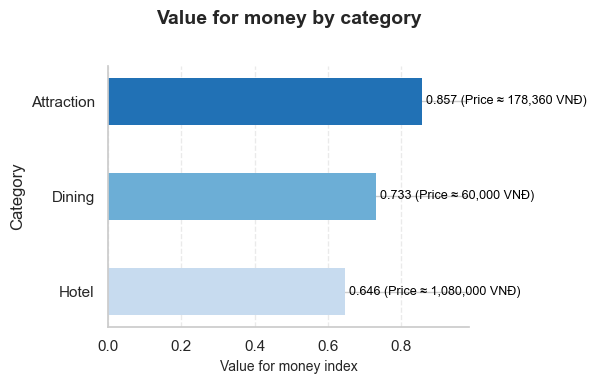

In [16]:
df_price = df.dropna(subset=['Score', 'Price_mean', 'Category'])
df_price = df_price[df_price['Price_mean'] > 0].copy()

# Tính Value-for-Money Index cho từng Category
cat_vfm = (
    df_price.groupby('Category', observed=True)
    .agg(
        Median_Score=('Score', 'median'),
        Median_Price=('Price_mean', 'median'),
        Count=('Score', 'count')
    )
    .reset_index()
)

# Index = Score / log10(Price)
cat_vfm['Value_Index'] = cat_vfm['Median_Score'] / np.log10(cat_vfm['Median_Price'])
cat_vfm = cat_vfm.sort_values('Value_Index', ascending=False).reset_index(drop=True)

# Vẽ biểu đồ horizontal bar chart cho Value-for-Money Index
fig, ax = plt.subplots(figsize=(6, 4)) 

bar_pal = sns.color_palette('Blues_r', len(cat_vfm))

bars = ax.barh(
    cat_vfm['Category'].astype(str),
    cat_vfm['Value_Index'],
    color=bar_pal,
    edgecolor='none',
    height=0.5
)

for i, row in cat_vfm.iterrows():
    ax.text(
        row['Value_Index'] + 0.01,
        i,
        f"{row['Value_Index']:.3f} (Price ≈ {row['Median_Price']:,.0f} VNĐ)",
        va='center', fontsize=9, color='black'
    )

ax.invert_yaxis() 
ax.set_xlim(0, cat_vfm['Value_Index'].max() * 1.15) 
ax.set_title(
    'Value for money by category\n',
    fontsize=14, fontweight='bold', pad=15, loc='center'
)

ax.set_xlabel('Value for money index', fontsize=10)
ax.set_ylabel('Category')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Insights:**
- Attractions lead in terms of value for money (index of 0.857) with a mid range cost (approx- imately 178,000 VND), indicating that users highly value the experience received compared to the amount spent.
- Conversely, the hotels, despite having the highest median price (over 1 million VND), recorded the lowest index (0.646), reflecting the fact that satisfaction does not increase proportionally with the high cost of accommodation.
- Dinings offer a fairly good value for money (0.733), mainly due to the advantage of very low access costs (approximately 60,000 VND), suitable for the vast majority of customers.

### 4.4 Distribution of scores by category (`score`, `category`)
The goal of this section is to compare the **distribution of scores** across location categories, while also identifying differences in median and dispersion.
- **Group boxplot**: displays the interquartile range (IQR), median, and outlier values ​​of the `Score` for each category.
- **Overlay strip plot**: displays individual data points (with high transparency) to supplement the picture of the actual density distribution of the underlying data.

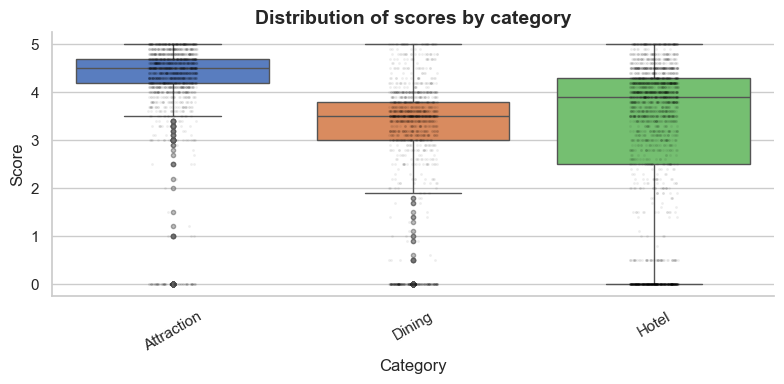

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(
    data=df, x='Category', y='Score',
    palette='muted', ax=ax,
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.5)
)
sns.stripplot(
    data=df, x='Category', y='Score',
    color='black', alpha=0.07, size=2, ax=ax, jitter=True
)

ax.set_title('Distribution of scores by category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Score')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


**Insights:**
- Attractions recorded the most stable and outstanding service quality with a high median score (approximately 4.5) and a narrow data distribution range (IQR), mainly concentrated in the excellent score range.
- In contrast, Hotels group showed strong differentiation in quality with a very wide range of scores, spanning from low average (2.5) to high (4.3).
- Dinings had the lowest overall average (median around 3.5). At the same time, all three categories showed many outliers extending down to the 0 mark, most likely locations that have not received actual evaluations.

### 4.5 Distribution of prices by category (`price_mean`, `category`)
The goal of this section is to compare the **service price segments** across different location categories.

Due to the strongly right-skewed distribution of the price variable with a very wide range of values ​​(from a few thousand to tens of millions of VND), the chart uses a **logarithm scale** on the Y-axis to ensure readability and comparability.

- **Group Boxplot**: shows the average price distribution range (`Price_mean`) of each category.

- **Overlapping strip plot**: shows the actual dispersion of price data within each group.


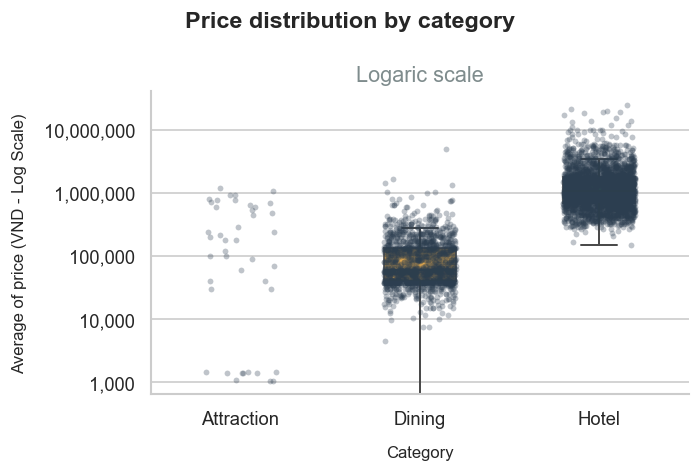

In [18]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
custom_palette = ['#4A90E2', '#F39C12', '#2ECC71'] 

# Vẽ Boxplot
sns.boxplot(
    data=df, x='Category', y='Price_mean', 
    palette=custom_palette, ax=ax, 
    showfliers=False, width=0.4, linewidth=1.2,
    boxprops=dict(alpha=0.85)
)

# Rải Stripplot
sns.stripplot(
    data=df, x='Category', y='Price_mean', 
    color='#2C3E50', alpha=0.3, jitter=0.2, size=3.5, ax=ax
)

ax.set_yscale('log')

# Căn chỉnh nhãn trục
ax.set_xlabel('Category', fontsize=10, labelpad=10)
ax.set_ylabel('Average of price (VND - Log Scale)', fontsize=10, labelpad=10)

ax.tick_params(axis='x', rotation=0, labelsize=11) 
ax.yaxis.set_major_formatter(price_fmt)

fig.suptitle('Price distribution by category', fontsize=14, fontweight='bold', y=0.98)
ax.set_title('Logaric scale', fontsize=13, color='#7F8C8D')

plt.tight_layout()
plt.show()


**Insights:**
- There is a clear differentiation in cost levels between services the hotel category has a high price range (median around 1 million VND), while the dining category mainly serves the budget segment (ranging from 40000 to 150000 VND).
- Both the hotels and dinings have a wide distribution range with many outliers reaching very high prices, indicating a diverse market offering everything from budget-friendly options to luxury services.
- The attractions, in particular, have very sparse and highly dispersed price data, reflecting the
unique reality of this group where many public places are free to enter.

### 4.6 Correlation between variables (`score`, `nums_comments`, `price_mean`)
The goal of this section is to visualize the **degree and magnitude of linear correlation** between the principal variables in the dataset.

The Pearson correlation matrix is ​​calculated and displayed as a heatmap for four variables: `score`, `nums_comments`, `price_min`, and `price_max`.

A diverging colormap is used to clearly distinguish between **positive correlation** (red/warm), **negative correlation** (blue/cold), and **uncorrelated** areas (white/pale); the correlation coefficient (r) is noted directly in each cell.

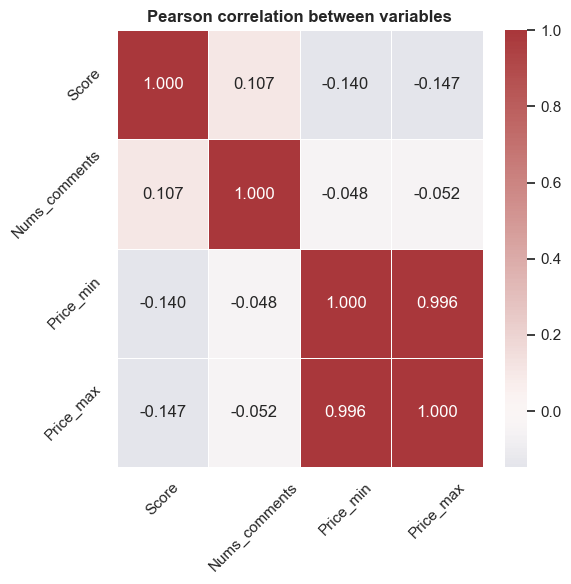

In [19]:
corr_cols   = ['Score', 'Nums_comments', 'Price_min', 'Price_max']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.3f',
    cmap='vlag', center=0,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 12},
    ax=ax
)
ax.set_title('Pearson correlation between variables', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=45)
plt.tight_layout()
plt.show()


**Insights:**
- The two variables price_min and price_max have a nearly absolute positive linear correlation (r = 0.996), reflecting very strong multicollinearity, suggesting that they should be combined into a single average value variable to optimize the machine learning model later.
- Score and nums_comments are almost independent of each other (r = 0.107), demonstrating that a location with high coverage and many comments does not necessarily mean it will achieve an excellent quality score.
- At the same time, the price shows a very weak negative correlation with the rating (r =-0.14), implying that customers tend to be a little more critical and more likely to give lower scores when experiencing services with higher costs.

### 4.7 Distribution of operating hours (`hours`)
The objective of this section is to analyze the **operating time patterns of locations** based on opening and closing time data.

Three charts are used to illustrate:

- **Opening time bar chart**: showing the frequency of opening hours.

- **Closing time bar chart**: showing the frequency of closing hours.

- **Opening-Closing time pair heatmap**: representing the combined distribution of two time variables to identify common operating hours.

Locations operating 24/7 are excluded from the opening/closing time distribution analysis to clarify the trends of the remaining hours.

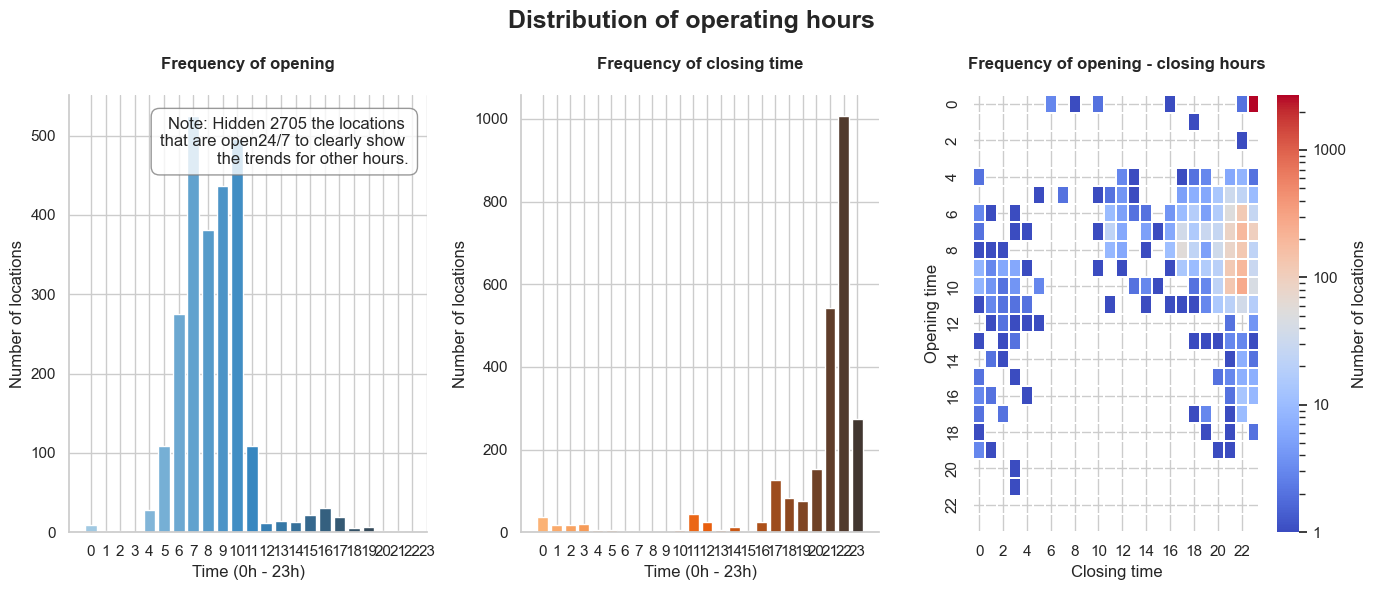

In [23]:
def extract_hour(t):
    """Trích xuất giờ nguyên từ chuỗi 'H:MM' hoặc 'HH:MM'."""
    try:
        return int(str(t).split(':')[0])
    except Exception:
        return None

df['Start_hour'] = df['Start'].apply(extract_hour)
df['End_hour']   = df['End'].apply(extract_hour)

# Xây dựng pivot: tần suất từng cặp (Start_hour, End_hour)
hours = list(range(0, 24))
time_matrix = pd.DataFrame(0, index=hours, columns=hours, dtype=int)

for _, row in df.dropna(subset=['Start_hour', 'End_hour']).iterrows():
    s, e = int(row['Start_hour']), int(row['End_hour'])
    time_matrix.at[s, e] += 1

fig, axes = plt.subplots(1, 3, figsize=(14, 6))
fig.suptitle('Distribution of operating hours', fontsize=18, fontweight='bold')

# Lọc ra các địa điểm không phải 24/7 (Ví dụ: Start != 0 hoặc End != 23)
is_247 = (df['Start_hour'] == 0) & (df['End_hour'] == 23)
df_normal = df[~is_247]
count_247 = is_247.sum()

# ----------------- CHART 1: GIỜ MỞ CỬA -----------------
start_counts = df_normal['Start_hour'].value_counts().sort_index()
axes[0].bar(start_counts.index, start_counts.values, color=sns.color_palette('Blues_d', len(start_counts)))
axes[0].set_title('Frequency of opening\n', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time (0h - 23h)')
axes[0].set_ylabel('Number of locations')
axes[0].set_xticks(range(0, 24))

# Text lưu ý về việc đã ẩn các địa điểm mở 24/7
axes[0].text(0.95, 0.95, f'Note: Hidden {count_247} the locations \nthat are open24/7 to clearly show \nthe trends for other hours.', 
             transform=axes[0].transAxes, ha='right', va='top', 
             bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.8, edgecolor='gray'))

# ----------------- CHART 2: GIỜ ĐÓNG CỬA -----------------
end_counts = df_normal['End_hour'].value_counts().sort_index()
axes[1].bar(end_counts.index, end_counts.values, color=sns.color_palette('Oranges_d', len(end_counts)))
axes[1].set_title('Frequency of closing time\n', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time (0h - 23h)')
axes[1].set_ylabel('Number of locations')
axes[1].set_xticks(range(0, 24))

# ----------------- CHART 3: HEATMAP -----------------
mask = time_matrix == 0

# Cấu hình formatter
formatter = ScalarFormatter()
formatter.set_scientific(False)

sns.heatmap(
    time_matrix,
    cmap='coolwarm',
    norm=LogNorm(), 
    mask=mask,
    ax=axes[2],
    linewidths=0.2,
    xticklabels=2,
    yticklabels=2,
    cbar_kws={
        'label': 'Number of locations',
        'format': formatter
    }
)
axes[2].set_title('Frequency of opening - closing hours\n', fontsize=12, fontweight='bold'   )
axes[2].set_xlabel('Closing time')
axes[2].set_ylabel('Opening time')

plt.tight_layout()
plt.show()


**Insights:**
- The most striking feature of the data is the prevalence of 24/7 operating hours, with over 2700 locations, indicating a very high level of availability to serve customers around the clock.
- For businesses with fixed operating hours, the majority choose to open in the morning (heavily concentrated from 6 am to 10 am) and close late in the evening (9 pm to 11 pm, peaking at 10 pm).
- The heatmap reinforces this trend with clusters of warm colors converging at corresponding time pairs, reflecting the commercial pace and service demand extending from early morning to late night.

### 4.8 Normalize addresses to coordinates (`address`, `lat`, `lon`)
The goal of this section is to **assign geographic coordinates (latitude, longitude)** to each location in the dataset to facilitate spatial data visualization on a map.

The implementation process includes the following main steps:

- **Address information extraction**: The `extract_address_info` function separates the `Address` column into `Ward`, `District`, and `Street`, and normalizes district names through the `district_alias` table.

- **Geocoding using the Nominatim API**: Unique addresses are sent to the **Nominatim (OpenStreetMap)** service to obtain `(lat, lon)` coordinates with a limit of **1 request/second** according to the API policy.

- **Fallback mechanism**: For addresses where coordinates cannot be found, the system assigns **district/county center coordinates** from the `hcm_district_coords` table to minimize data loss.

The final results are stored in two new columns of the DataFrame: **`lat`** and **`lon`**.

In [3]:
hcm_district_coords = {
    "Quận 1": (10.775659, 106.700424),
    "Quận 3": (10.784200, 106.684400),
    "Quận 4": (10.759000, 106.704000),
    "Quận 5": (10.754000, 106.663000),
    "Quận 6": (10.748000, 106.635000),
    "Quận 7": (10.734000, 106.721000),
    "Quận 8": (10.724000, 106.631000),
    "Quận 10": (10.770000, 106.667000),
    "Quận 11": (10.763000, 106.650000),
    "Quận 12": (10.867000, 106.654000),

    "Bình Thạnh": (10.804659, 106.707848),
    "Gò Vấp": (10.838700, 106.665300),
    "Phú Nhuận": (10.801667, 106.677500),
    "Tân Bình": (10.801500, 106.652700),
    "Tân Phú": (10.791000, 106.627000),
    "Bình Tân": (10.765000, 106.603000),

    "Thành phố Thủ Đức": (10.849000, 106.753000),

    "Huyện Bình Chánh": (10.694000, 106.598000),
    "Huyện Củ Chi": (11.006000, 106.513000),
    "Huyện Hóc Môn": (10.889000, 106.592000),
    "Huyện Nhà Bè": (10.678000, 106.733000),
    "Huyện Cần Giờ": (10.411000, 106.954000)
}

district_alias = {
    "Quận 1": ["quận 1", "q1", "q.1", "1"],
    "Quận 3": ["quận 3", "q3", "q.3", "3"],
    "Quận 4": ["quận 4", "q4", "q.4", "4"],
    "Quận 5": ["quận 5", "q5", "q.5", "5"],
    "Quận 6": ["quận 6", "q6", "q.6", "6"],
    "Quận 7": ["quận 7", "q7", "q.7", "7"],
    "Quận 8": ["quận 8", "q8", "q.8", "8"],
    "Quận 10": ["quận 10", "q10", "q.10", "10"],
    "Quận 11": ["quận 11", "q11", "q.11", "11"],
    "Quận 12": ["quận 12", "q12", "q.12", "12"],

    "Bình Thạnh": ["bình thạnh", "quận bình thạnh", "q.bình thạnh", "q bình thạnh"],
    "Gò Vấp": ["gò vấp", "quận gò vấp", "q.gò vấp", "q gò vấp"],
    "Phú Nhuận": ["phú nhuận", "quận phú nhuận", "q.phú nhuận"],
    "Tân Bình": ["tân bình", "quận tân bình", "q.tân bình"],
    "Tân Phú": ["tân phú", "quận tân phú", "q.tân phú"],
    "Bình Tân": ["bình tân", "quận bình tân", "q.bình tân"],

    # Thủ đức bao gồm: quận 2, quận 9, quận thủ đức
    "Thành phố Thủ Đức": [
        "thủ đức",
        "tp thủ đức",
        "thành phố thủ đức",
        "quận thủ đức",
        "q.thủ đức",
        "quận 2", "q2", "q.2", "2",
        "quận 9", "q9", "q.9", "9",

    ],

    "Huyện Củ Chi": ["củ chi", "huyện củ chi"],
    "Huyện Hóc Môn": ["hóc môn", "huyện hóc môn"],
    "Huyện Bình Chánh": ["bình chánh", "huyện bình chánh"],
    "Huyện Nhà Bè": ["nhà bè", "huyện nhà bè"],
    "Huyện Cần Giờ": ["cần giờ", "huyện cần giờ"]
}

def extract_address_info(address):
    if not isinstance(address, str):
        return None, None, None
        
    parts = [p.strip() for p in address.split(',')]
    
    ward = None
    district = None
    raw_street = None
    
    # Duyệt qua từng phần tử sau khi tách bởi dấu phẩy
    for part in parts:
        part_lower = part.lower()
        
        # KIỂM TRA QUẬN
        is_district = False
        for std_name, aliases in district_alias.items():
            if part_lower in aliases:
                district = std_name # Gán luôn tên chuẩn (VD: "District 1")
                is_district = True
                break
        
        if is_district:
            continue
            
        # KIỂM TRA PHƯỜNG
        if part_lower.startswith(('phường', 'p.', 'phuong', 'p ')):
            ward = part
            continue
            
        # KIỂM TRA ĐƯỜNG
        if raw_street is None:
            raw_street = part

    # Xử lý raw_street để loại bỏ các thông tin phụ nếu có => chỉ giữ lại tên đường
    street = None
    if raw_street:
        street = re.sub(r'^[\d/a-zA-Z-]+\s+', '', raw_street).strip()
        if len(street) < 3: 
            street = None
            
    return ward, district, street

# Cập nhật DataFrame
df['Ward'], df['District'], df['Street'] = zip(*df['Address'].apply(extract_address_info))


In [8]:
NOMINATIM_URL = "https://nominatim.openstreetmap.org/search"
MAX_GEOCODE = 6000
CACHE_FILE = "../data/coord_cache.json"  # Lưu trữ kết quả geocoding

def geocode_address(address: str):
    try:
        params = {
            "q": f"{address}, Hồ Chí Minh, Việt Nam",
            "format": "json",
            "limit": 1,
            "countrycodes": "vn",
        }
        headers = {"User-Agent": "CSC14005-ML-Lab/1.0"}
        resp = requests.get(NOMINATIM_URL, params=params, headers=headers, timeout=10)
        resp.raise_for_status()
        results = resp.json()
        if results:
            return float(results[0]["lat"]), float(results[0]["lon"])
    except Exception:
        pass
    return None, None

coord_cache = {}

# Load dữ liệu cache từ file nếu đã tồn tại
if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE, "r", encoding="utf-8") as f:
        coord_cache = json.load(f)

# Lấy các địa chỉ duy nhất để giảm số lần gọi API
unique_addrs = df['Address'].dropna().unique()[:MAX_GEOCODE]

# Kiểm tra nếu đã có dữ liệu lat - lon của trên 1000 dữ liệu thì khỏi gọi API
if len(coord_cache) > 1000:
    print(f"The {len(coord_cache)} mode is already in the cache. Skip the API call")
else:
    print(f"Geocoding {len(unique_addrs)} unique locations (1 req/second)...")
    
    for i, addr in enumerate(unique_addrs):
        if addr not in coord_cache:
            coord_cache[addr] = geocode_address(addr)
            _time.sleep(1)
        if (i + 1) % 50 == 0:
            print(f"  [{i + 1}/{len(unique_addrs)}] processed...")
            
    # Lưu lại dữ liệu lat - lon để dùng sau này
    with open(CACHE_FILE, "w", encoding="utf-8") as f:
        json.dump(coord_cache, f, ensure_ascii=False, indent=4)

# Map lat/lon về DataFrame gốc
df['lat'] = df['Address'].map(lambda a: coord_cache.get(a, (None, None))[0])
df['lon'] = df['Address'].map(lambda a: coord_cache.get(a, (None, None))[1])

# Fallback: dùng tọa độ trung tâm quận cho các dòng Nominatim không tìm được
mask_missing = df['lat'].isna()
df.loc[mask_missing, 'lat'] = df.loc[mask_missing, 'District'].map(
    lambda d: hcm_district_coords.get(d, (None, None))[0]
)
df.loc[mask_missing, 'lon'] = df.loc[mask_missing, 'District'].map(
    lambda d: hcm_district_coords.get(d, (None, None))[1]
)

n_nominatim = (~mask_missing).sum()
n_fallback  = (mask_missing & df['lat'].notna()).sum()
n_total     = df['lat'].notna().sum()
print(f"\nNominatim: {n_nominatim} | Fallback district: {n_fallback} | Empty: {df['lat'].isna().sum()}")
print(f"Total has coordinates: {n_total}/{len(df)} rows ({n_total/len(df)*100:.1f}%)")


The 5200 mode is already in the cache. Skip the API call

Nominatim: 1110 | Fallback district: 4817 | Empty: 111
Total has coordinates: 5927/6038 rows (98.2%)


In [11]:
# Lọc các dòng lấy được tọa độ thành công
geo_df = df.dropna(subset=['lat', 'lon', 'Category', 'Price_mean']).copy()
geo_df['District'] = geo_df['District'].fillna('Không xác định')

# Vẽ Scatter Mapbox chi tiết
fig1 = px.scatter_mapbox(
    geo_df, 
    lat="lat", 
    lon="lon", 
    color="Category",
    hover_name="Address",
    hover_data={
        "District": True,
        "lat": False, "lon": False, 
        "Price_mean": ":,.0f"
    },
    # Tone màu tươi, hiện đại
    color_discrete_map={'Hotel': '#EF553B', 'Dining': '#FECB52', 'Attraction': '#00CC96'},
    zoom=10.2,
    center={"lat": 10.7826, "lon": 106.7009}, 
    mapbox_style="carto-positron",
    title="<b>Location by category</b><br><sup>Overview map of the area for attractions, dinings, and hotels.</sup>"
)

# Cập nhật size và độ trong suốt
fig1.update_traces(
    marker=dict(
        size=9,
        opacity=0.75
    )
)

fig1.update_layout(
    margin={"r":15, "t":70, "l":15, "b":15},
    title_x=0.5,
    title_font=dict(size=22),
    paper_bgcolor="#f4f6f9",
    
    # Legend
    legend=dict(
        title="<b>Category</b>",
        yanchor="top",
        y=0.98,
        xanchor="left",
        x=0.02,
        bgcolor="rgba(255, 255, 255, 0.85)",
        bordercolor="gray",
        borderwidth=1,
        font=dict(size=13)
    )
)

fig1.show()


**Insigts:**
- The highest concentration of service facilities is found in the city center.
-In contrast to the clustering of accommodation, the attractions and dinings show a more widespread distribution and expansion into neighboring districts and counties.
- The close intermingling of these three categories on the map clearly reflects the formation of integrated tourism-service ecosystems, comprehensively meeting the needs of tourists in the same area.

In [16]:
# Giới hạn giá trần (loại bỏ outliers) để bản đồ nhiệt hiển thị rõ hơn
price_cap = geo_df['Price_mean'].quantile(0.95)
geo_df['Price_Heat'] = geo_df['Price_mean'].clip(upper=price_cap)

# Vẽ Bản đồ Nhiệt (Density Mapbox)
fig2 = px.density_mapbox(
    geo_df, 
    lat='lat', 
    lon='lon', 
    z='Price_Heat',
    radius=15,
    center=dict(lat=10.7769, lon=106.7009), 
    zoom=1,
    mapbox_style="carto-positron", 
    color_continuous_scale="YlGnBu", 
    
    title="<b>Heatmap of price</b><br><sup>Identify expensive (dark green) and cheap (light yellow) areas.</sup>",
    hover_data={
        "District": True,
        "Price_mean": ":,.0f",
        "Price_Heat": False,
        "lat": False,
        "lon": False
    }
)

fig2.update_layout(
    margin={"r":15, "t":70, "l":15, "b":15}, 
    title_x=0.5,                             
    title_font=dict(size=22),
    paper_bgcolor="#f4f6f9",                 
    
    mapbox=dict(
        center=dict(lat=10.7826, lon=106.6601),
        zoom=10.2,
        style="carto-positron"
    ),

    coloraxis_colorbar=dict(
        title="<b>Price (VNĐ)</b>",
        thickness=15,                         
        len=0.65,                             
        yanchor="top", y=0.98,                
        xanchor="right", x=0.98,              
        bgcolor="rgba(255, 255, 255, 0.85)",  
        bordercolor="gray",                   
        borderwidth=1,                        
        tickformat=",.0f",                    
        tickfont=dict(size=12),   
        title_font=dict(size=13)   
    )
)

fig2.show()


**Insights:**
- The heat map shows a clear spatial differentiation in cost, with the most expensive services (dark green area, prices above 2 million VND) densely concentrated in large clusters in the city center.
- Conversely, when expanding to the suburban districts and areas, the color intensity decreases significantly and shifts to a light yellow tone, indicating the dominance of the affordable service segment (below 500000 VND).
- This pricing positioning closely reflects the law of commercial land rent, confirming that service costs are directly proportional to the prime location and centrality of the geographical position.

### 4.9 Location density and pricing by area (`lat`, `lon`, `price_mean`, `category`)
The goal of this section is to **visualize the geographical spatial distribution** of locations on a map of Ho Chi Minh City, combined with an analysis of price differences across different areas.

This section includes a dashboard-style summary chart by district with four components:

- **Quantity density chart**: analyzing the top 15 districts with the most locations, color-coded by category.

- **Average price bar chart - Hotel**: comparing average accommodation prices across districts.

- **Average price bar chart - Dining**: comparing average dining costs across different areas.

- **Average price bar chart - Attraction**: comparing sightseeing costs across different areas.

The charts share the same Y-axis (district name) for convenient comparison of quantity and price levels across each geographical area.


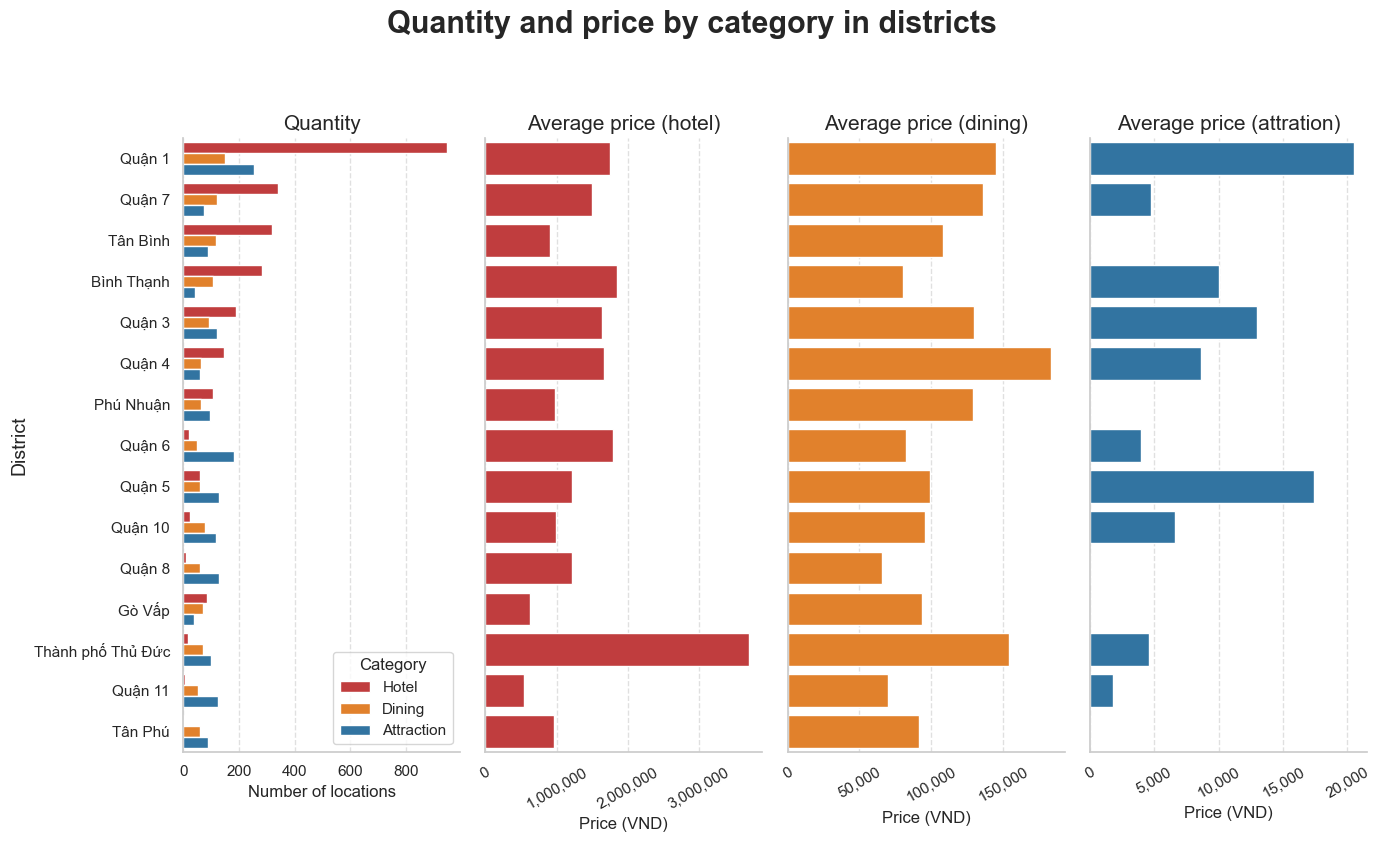

In [18]:
# Chuẩn bị dữ liệu: Lọc Top 15 Quận
plot_df = df.dropna(subset=['District', 'Category', 'Price_mean']).copy()
plot_df['Category'] = plot_df['Category'].str.title() 
top_districts = plot_df['District'].value_counts().head(15).index
df_top = plot_df[plot_df['District'].isin(top_districts)]

# Tính giá trung bình theo danh mục
price_hotel = df_top[df_top['Category'] == 'Hotel'].groupby('District')['Price_mean'].mean()
price_dining = df_top[df_top['Category'] == 'Dining'].groupby('District')['Price_mean'].mean()
price_attr = df_top[df_top['Category'] == 'Attraction'].groupby('District')['Price_mean'].mean()

# Vẽ biểu đồ tổng quan với 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(14, 8), sharey=True)
fig.suptitle('Quantity and price by category in districts', fontsize=22, fontweight='bold', y=1.05)
colors = {'Hotel': '#d62728', 'Dining': '#ff7f0e', 'Attraction': '#1f77b4'}

# --- Subplot 1: Mật độ Số lượng ---
sns.countplot(data=df_top, y='District', hue='Category', order=top_districts, palette=colors, ax=axes[0])
axes[0].set_title('Quantity', fontsize=15)
axes[0].set_xlabel('Number of locations', fontsize=12)
axes[0].set_ylabel('District', fontsize=14)
axes[0].legend(title='Category', loc='lower right')

# --- Subplot 2: Giá Hotel ---
sns.barplot(x=price_hotel.values, y=price_hotel.index, order=top_districts, ax=axes[1], color=colors['Hotel'])
axes[1].set_title('Average price (hotel)', fontsize=15)
axes[1].set_xlabel('Price (VND)', fontsize=12)
axes[1].xaxis.set_major_formatter(price_fmt)
axes[1].tick_params(axis='x', rotation=30) 

# --- Subplot 3: Giá Dining ---
sns.barplot(x=price_dining.values, y=price_dining.index, order=top_districts, ax=axes[2], color=colors['Dining'])
axes[2].set_title('Average price (dining)', fontsize=15)
axes[2].set_xlabel('Price (VND)', fontsize=12)
axes[2].xaxis.set_major_formatter(price_fmt)
axes[2].tick_params(axis='x', rotation=30)

# --- Subplot 4: Giá Attraction ---
sns.barplot(x=price_attr.values, y=price_attr.index, order=top_districts, ax=axes[3], color=colors['Attraction'])
axes[3].set_title('Average price (attration)', fontsize=15)
axes[3].set_xlabel('Price (VND)', fontsize=12)
axes[3].xaxis.set_major_formatter(price_fmt)
axes[3].tick_params(axis='x', rotation=30)

for ax in axes:
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    
plt.tight_layout()
plt.show()

**Insights:**
- In terms of density, district 1 serves as the core accommodation and tourism hub, with an overwhelming number of hotel establishments compared to the rest of the city.
- However, in terms of cost, Thu Duc city surprisingly has the highest average hotel room price (exceeding 3.5 million VND), creating a significant gap compared to the city center.
- In other categories, the price segment also shows an interesting differentiation, district 4 leads in average food costs, while sightseeing costs remain extremely low throughout the district, only slightly higher in districts 5 and 1.

## 5. Text analysis
The goal of this section is to extract information from **unstructured data**, including text-based comments and individual rating data, to add a qualitative perspective to the overall analysis.

### 5.1 Keywords featured in comments and location names (`comments`, `name`)
The goal of this section is to **visualize the most frequently appearing keywords** in comments and place names.

Two Word clouds were created:

- **Word cloud — Comments**: aggregates all comment text from the `comments` column, highlighting characteristic words frequently mentioned by users (service quality, location, experience, etc.). Common Vietnamese and English stopwords have been excluded to avoid noise.

- **Word cloud — Name**: aggregates the names of places in the dataset, helping to identify common keywords in the names (e.g., district name, type of service, etc.).

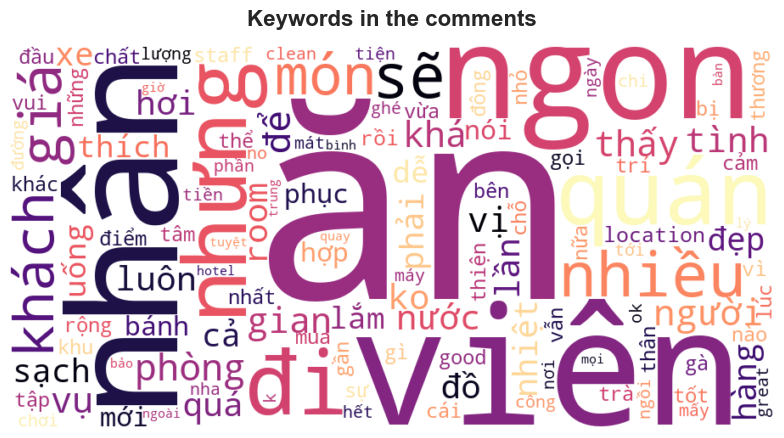

In [5]:
# Gom toàn bộ text từ danh sách comment
all_comment_text = ' '.join(
    comment
    for comment_list in df['Comments']
    for comment in comment_list
    if isinstance(comment, str) and comment.strip()
)

# Danh sách Stopwords
STOPWORDS = {
    # Tiếng Việt
    'và', 'của', 'là', 'có', 'không', 'được', 'cho', 'với', 'trong', 'một',
    'này', 'đã', 'tôi', 'thì', 'rất', 'ở', 'từ', 'hơn', 'cũng', 'như',
    'khi', 'nên', 'lên', 'làm', 'vào', 'ra', 'lại', 'thêm', 'bạn', 'nhà',
    'mình', 'còn', 'nếu', 'chỉ', 'về', 'hay', 'mà', 'đến', 'đây', 'đó',
    'các', 'ở', 'tại', 'theo', 'qua', 'sau', 'trước', 'trên', 'dưới',
    # Tiếng Anh
    'the', 'a', 'an', 'is', 'it', 'in', 'on', 'at', 'of', 'and', 'or',
    'but', 'was', 'are', 'be', 'we', 'my', 'i', 'you', 'this', 'that',
    'for', 'not', 'with', 'as', 'to', 'he', 'she', 'they', 'its', 'our',
    'so', 'if', 'by', 'do', 'did', 'has', 'had', 'have', 'were', 'been',
    'would', 'could', 'will', 'can', 'may', 'also', 'very', 'from', 'all',
}

# ======== Word Cloud 1: Từ khóa trong Comments ========
text_c = all_comment_text.strip() or 'no data'
wc_comments = WordCloud(
    width=900, height=450,
    background_color='white',
    stopwords=STOPWORDS,
    max_words=120,
    colormap='magma',
    collocations=False,
    prefer_horizontal=0.8
).generate(text_c)

plt.figure(figsize=(8, 6))
plt.imshow(wc_comments, interpolation='bilinear')
plt.title('Keywords in the comments', fontsize=16, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()


**Insights:**
- The most prominent keywords are “ngon”, “quán” and “nhân viên” indicating that customer reviews focus primarily on food quality and service attitude.
- The significant appearance of words like “nhưng" and “không" suggests that many comments include comparisons or two-sided reviews (praise and criticism).
- Words related to service experience such as “phòng”, “sạch sẽ", “vị trí” and “giá" also appear, reflecting customer interest in space and amenities beyond food.

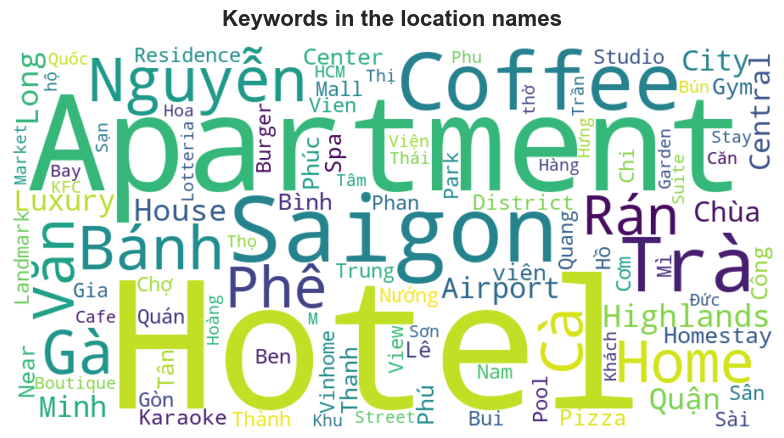

In [ ]:
all_name_text = ' '.join(df['Name'].dropna().astype(str))

text_n = all_name_text.strip() or 'no data'
wc_names = WordCloud(
    width=900, height=450,
    background_color='white',
    stopwords=STOPWORDS,
    max_words=100,
    colormap='viridis',
    collocations=False,
    prefer_horizontal=0.7
).generate(text_n)

plt.figure(figsize=(8, 6))
plt.imshow(wc_names, interpolation='bilinear')
plt.title('Keywords in the location names', fontsize=16, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()


**Insights:**
- Nouns identifying service types such as “Hotel", “Apartment",“Coffee" and “cà phê" dominate, reflecting the overwhelming number of accommodation and beverage establishments in the dataset.
- Geographical location factors are thoroughly exploited in brand naming, as evidenced by the frequent appearance of the keyword “Saigon" and popular street names (such as “Nguyễn”).
- For the food group, highly distinctive and easily recognizable dishes such as “Gà", “Bánh" or “Trà" are often directly included in the names by business owners to attract target customers.